In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import config, plotting
from dimelo import parse_bam, plot_enrichment, load_processed

In [2]:
lmnb1_bam_file = config.processed_data_dir / "barcode24.bam"

cLAD = {
    "bed_file": config.processed_data_dir / "cLAD_gold_final_250kb.t2t_chm13v2.bed",
    "motif": "A,0",
    "id": "gold cLADs",
}
ciLAD = {
    "bed_file": config.processed_data_dir / "ciLAD_gold_final_250kb.t2t_chm13v2.bed",
    "motif": "A,0",
    "id": "gold ciLADs"
}
on_target_accessibility = {
    "bed_file": config.processed_data_dir / "gm12878_accessibility.on_target.bed",
    "motif": "GCH,1",
    "id": "active TSSs"
}
off_target_accessibility = {
    "bed_file": config.processed_data_dir / "gm12878_accessibility.off_target.bed",
    "motif": "GCH,1",
    "id": "active TSS\nflanking regions"
}
on_target_CG = {
    "bed_file": config.processed_data_dir / "gm12878_cpg.on_target.bed",
    "motif": "WCG,1",
    "id": "inactive TSS\nCpG islands"
}
off_target_CG = {
    "bed_file": config.processed_data_dir / "gm12878_cpg.off_target.bed",
    "motif": "WCG,1",
    "id": "active TSS\nCpG islands"
}
condition_dicts = [cLAD, ciLAD, on_target_accessibility, off_target_accessibility, on_target_CG, off_target_CG]
A_dicts = [cLAD, ciLAD]
GC_dicts = [on_target_accessibility, off_target_accessibility]
CG_dicts = [on_target_CG, off_target_CG]
on_target_dicts = [cLAD, on_target_accessibility, on_target_CG]
off_target_dicts = [ciLAD, off_target_accessibility, off_target_CG]

In [3]:
reference_file = config.raw_data_dir / "chm13v2.0.fa"

mod_prob_thresh = 0.95
n_cores = 10

In [ ]:
for condition_dict in condition_dicts:
    output_id = ".".join([lmnb1_bam_file.stem, condition_dict['bed_file'].stem])
    parse_bam.pileup(
        input_file=lmnb1_bam_file,
        output_name=f"pileup.{output_id}",
        output_directory=config.processed_data_dir,
        ref_genome=reference_file,
        regions=condition_dict["bed_file"],
        motifs=[condition_dict["motif"]],
        thresh=mod_prob_thresh,
        window_size=None,
        cores=n_cores,
        override_checks=True,
    )
    parse_bam.extract(
        input_file=lmnb1_bam_file,
        output_name=f"extract.{output_id}",
        ref_genome=reference_file,
        output_directory=config.processed_data_dir,
        regions=condition_dict["bed_file"],
        motifs=[condition_dict["motif"]],
        thresh=None, # No thresholding at extract time
        window_size=None,
        cores=n_cores,
        override_checks=True,
    )

# Main text figures

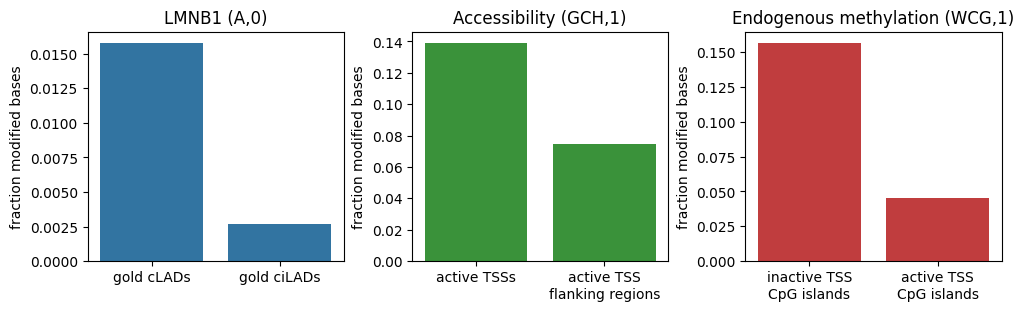

In [4]:
fig, axes = plt.subplots(1, 3, layout="constrained", figsize=(10, 3))


plot_enrichment.plot_enrichment(
    mod_file_names=[config.processed_data_dir / f"pileup.{lmnb1_bam_file.stem}.{condition_dict['bed_file'].stem}" / "pileup.sorted.bed.gz" for condition_dict in A_dicts],
    regions_list=[condition_dict["bed_file"] for condition_dict in A_dicts],
    motifs=[condition_dict["motif"] for condition_dict in A_dicts],
    sample_names=[condition_dict["id"] for condition_dict in A_dicts],
    palette = {condition_dict["id"]: plotting.default_palette_map[condition_dict["motif"]] for condition_dict in A_dicts},
    quiet=True,
    ax=axes[0]
)
axes[0].set_title("LMNB1 (A,0)")
plot_enrichment.plot_enrichment(
    mod_file_names=[config.processed_data_dir / f"pileup.{lmnb1_bam_file.stem}.{condition_dict['bed_file'].stem}" / "pileup.sorted.bed.gz" for condition_dict in GC_dicts],
    regions_list=[condition_dict["bed_file"] for condition_dict in GC_dicts],
    motifs=[condition_dict["motif"] for condition_dict in GC_dicts],
    sample_names=[condition_dict["id"] for condition_dict in GC_dicts],
    palette = {condition_dict["id"]: plotting.default_palette_map[condition_dict["motif"]] for condition_dict in GC_dicts},
    quiet=True,
    ax=axes[1]
)
axes[1].set_title("Accessibility (GCH,1)")
plot_enrichment.plot_enrichment(
    mod_file_names=[config.processed_data_dir / f"pileup.{lmnb1_bam_file.stem}.{condition_dict['bed_file'].stem}" / "pileup.sorted.bed.gz" for condition_dict in CG_dicts],
    regions_list=[condition_dict["bed_file"] for condition_dict in CG_dicts],
    motifs=[condition_dict["motif"] for condition_dict in CG_dicts],
    sample_names=[condition_dict["id"] for condition_dict in CG_dicts],
    palette = {condition_dict["id"]: plotting.default_palette_map[condition_dict["motif"]] for condition_dict in CG_dicts},
    quiet=True,
    ax=axes[2]
)
axes[2].set_title("Endogenous methylation (WCG,1)")

plt.savefig(config.figure_dir / "lmnb1.plot_enrichment.svg")
plt.show()
plt.close()

# Supplemental Figures

In [5]:
rng = np.random.default_rng()
mod_event_sample_size = 200000  # subsetting mod events to save on time and memory

In [6]:
on_target_motif_mod_vector_dict = {}
for condition_dict in on_target_dicts:
    read_tuples, entry_labels, _ = load_processed.read_vectors_from_hdf5(
        file=config.processed_data_dir / f"extract.{lmnb1_bam_file.stem}.{condition_dict['bed_file'].stem}" / "reads.combined_basemods.h5",
        motifs=[condition_dict["motif"]],
        regions=condition_dict["bed_file"],
        single_strand=False,
        sort_by="shuffle",
        calculate_mod_fractions=False,
    )
    mod_vector_index = entry_labels.index("mod_vector")
    val_vector_index = entry_labels.index("val_vector")
    mod_vector = np.concatenate([read_tuple[mod_vector_index][read_tuple[val_vector_index] == 1] for read_tuple in read_tuples])
    on_target_motif_mod_vector_dict[condition_dict["motif"]] = rng.choice(mod_vector, mod_event_sample_size)

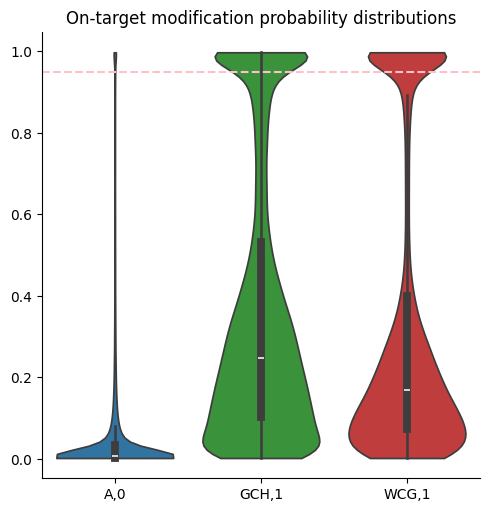

In [7]:
fig = sns.catplot(on_target_motif_mod_vector_dict, kind="violin", cut=0, palette=plotting.default_palette_map)
plt.axhline(mod_prob_thresh, linestyle="--", color="pink")
plt.title("On-target modification probability distributions")

plt.savefig(config.figure_dir / "lmnb1.mod_probs.on_target.svg")
plt.show()
plt.close()

In [8]:
off_target_motif_mod_vector_dict = {}
for condition_dict in off_target_dicts:
    read_tuples, entry_labels, _ = load_processed.read_vectors_from_hdf5(
        file=config.processed_data_dir / f"extract.{lmnb1_bam_file.stem}.{condition_dict['bed_file'].stem}" / "reads.combined_basemods.h5",
        motifs=[condition_dict["motif"]],
        regions=condition_dict["bed_file"],
        single_strand=False,
        sort_by="shuffle",
        calculate_mod_fractions=False,
    )
    mod_vector_index = entry_labels.index("mod_vector")
    val_vector_index = entry_labels.index("val_vector")
    mod_vector = np.concatenate([read_tuple[mod_vector_index][read_tuple[val_vector_index] == 1] for read_tuple in read_tuples])
    off_target_motif_mod_vector_dict[condition_dict["motif"]] = rng.choice(mod_vector, mod_event_sample_size)

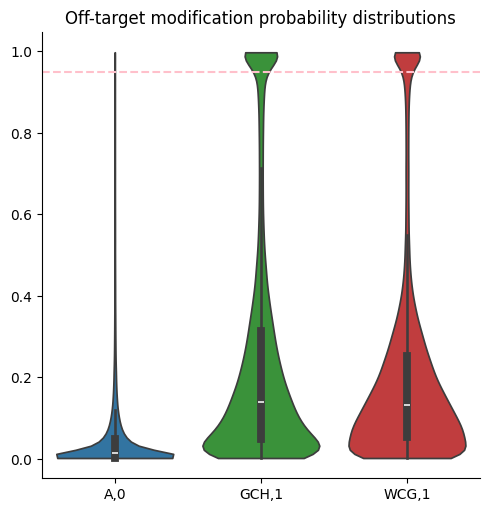

In [9]:
fig = sns.catplot(off_target_motif_mod_vector_dict, kind="violin", cut=0, palette=plotting.default_palette_map)
plt.axhline(mod_prob_thresh, linestyle="--", color="pink")
plt.title("Off-target modification probability distributions")

plt.savefig(config.figure_dir / "lmnb1.mod_probs.off_target.svg")
plt.show()
plt.close()